In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

import json

from settings import x_token, s_token, host, postgre_bd, user, psw
import funcs_yum as fy

In [30]:
posgdb = fy.PostgresDB(host, postgre_bd, user, psw)

# main

In [31]:
main_anime_df = pd.read_sql_query(
    '''
    SELECT *
    FROM anime_main AS m
        LEFT JOIN ratings AS r ON r.anime_id = m.anime_id
        LEFT JOIN ratings_distributions AS rd ON rd.anime_id = m.anime_id
    ORDER BY m.anime_id
    ''',
    posgdb.conn
)

main_copy = main_anime_df.copy()

C:\Users\gusen\AppData\Local\Temp\ipykernel_29520\215475660.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  main_anime_df = pd.read_sql_query(


In [32]:
main_anime_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10197 entries, 0 to 10196
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   anime_id            10197 non-null  int64  
 1   title               10197 non-null  str    
 2   description         10197 non-null  str    
 3   duration            10197 non-null  int64  
 4   anime_url           10197 non-null  str    
 5   year                10197 non-null  int64  
 6   season              10197 non-null  int64  
 7   views               10197 non-null  int64  
 8   status_ru           10197 non-null  str    
 9   type_ru             10197 non-null  str    
 10  rating_all          10197 non-null  int64  
 11  rating_category     10197 non-null  int64  
 12  original_source     10197 non-null  str    
 13  episodes_count      10197 non-null  int64  
 14  comments_count      10197 non-null  int64  
 15  lists_count         10197 non-null  int64  
 16  anime_id       

In [33]:
main_anime_df.head()

,anime_id,title,description,duration,anime_url,year,season,views,status_ru,type_ru,...,rat_1,rat_2,rat_3,rat_4,rat_5,rat_6,rat_7,rat_8,rat_9,rat_10
0,1,Ведьма-неудачница: Фука и тёмная ведьма,"Фука — неуклюжая принцесса, прозванная «Ведьмо...",3579,22-7,2023,1,47612,вышел,Короткометражный фильм,...,3,1,1,3,11,11,10,5,1,11
1,2,5 сантиметров в секунду,"Что происходит, когда два человека любят друг ...",3766,5-santimetrov-v-sekundu,2007,2,259721,вышел,Полнометражный фильм,...,32,12,31,62,177,281,546,583,410,631
2,3,"А ты думал, что твоя жена в онлайн-игре на сам...",В центре сюжета как обычно простой школьник-по...,17711,a-ty-dumal-chto-tvoya-zhena-v-onlajn-igre-na-s...,2016,2,244225,вышел,Сериал,...,24,18,40,68,183,331,407,239,78,159
3,4,A3! Осень и зима,"Компания «Манкай» далека от тех славных дней, ...",17124,a3-osen-i-zima,2020,4,32503,вышел,Сериал,...,2,1,2,2,8,4,7,8,3,11
4,5,A3! Весна и лето,"Театр «Манкай» находится на грани разорения, н...",17149,a3-vesna-i-leto,2020,1,27999,вышел,Сериал,...,4,1,0,0,7,5,5,11,3,16


## Всего на момент выгрузки на сайте было 10197 разных тайтлов 

## Распределение аниме по году выпуска
Тут можно указать две даты, после которы начинается рост количества выпускаемых аниме: 
- с 1985 начали выпускать аниме сразу на касетах без показа на больших экранах
- в 2000 наклыдывается множество факторов: переход к цифровой рисовке, развитие жанров для взрослой аудитории, 
    переход от длиносерийного производства (100+ серий) к более короткому формату (12/24 серий)

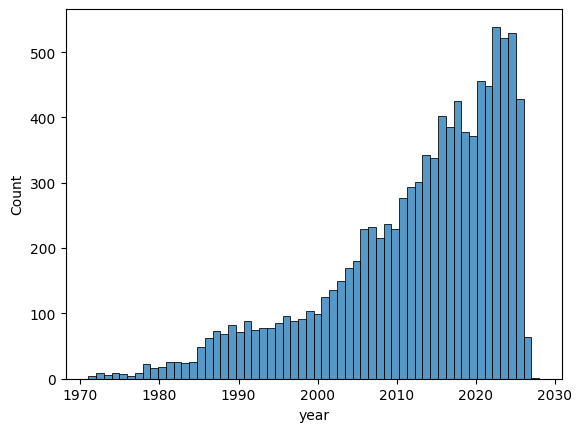

In [7]:
mask = main_anime_df['year']>1970
data = main_anime_df[mask].groupby('year')['anime_id'].count()

n_bins = len(data)
sns.histplot(main_anime_df[mask]['year'], bins=n_bins)

plt.title('')
plt.show()

## Распределение аниме по периодам года 

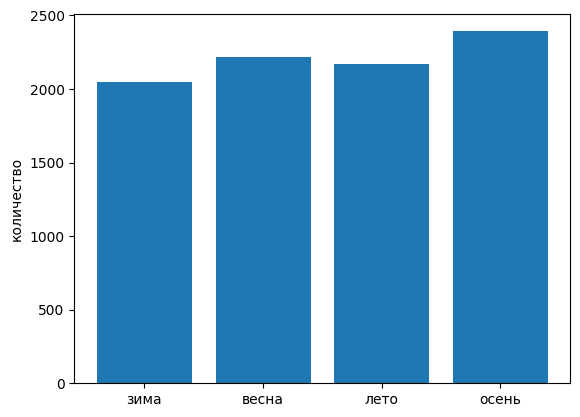

In [8]:
# season (зима, весна, лето, осень)
season = {1:'зима', 2:'весна', 3:'лето', 4:'осень'}

mask = main_anime_df['season']>0
data = main_anime_df[mask].groupby('season')['anime_id'].count()
data = data.rename(index=season)

n_bins = len(data)
plt.bar(data.index, data)

plt.title('')
plt.ylabel('количество')
plt.show()

## Распределение аниме по продолжительности (в секундах)

На распределениии по продолжительности выделяются три пика  
Эти пики можно охарактеризовать, если принять что в среднем в аниме сериале серии длятся по 24-25 минут  
тогда 3 группы это:
1) 34.000 - 38.000 секунд = 570 - 640 минут = 24/25 серии в среднем (с учетом средней длительности 1 серии)
2) 17.000 - 19.000 секунд = 280 - 320 минут = 12/13 серии в среднем
3) < 8000 = 130 минут 

Т.е. Среди всех аниме больше всего 12 и 24 серийников, + группа аниме длительностью менее двух часов (фильмы, короткие сериалы < 6 серий)

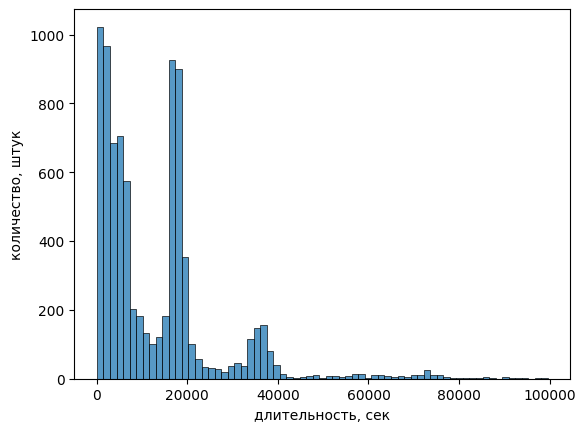

In [9]:
mask1 = main_anime_df['duration']>0
mask2 = main_anime_df['duration']<100000

sns.histplot(main_anime_df['duration'].where(mask1 & mask2))

plt.title('')
plt.xlabel('длительность, сек')
plt.ylabel('количество, штук')
plt.show()

При детальном рассмотрении группы, в которой продолжительность < 8000 секунд  
так же можно выделить 3 группы:  
1) 5.000 - 7.000 секунд = 80 - 120 минут - это полнометражные фильмы
2) 2600 -3400 секунд = 40 - 60 минут - либо 2 серии спешиала, либо 1 более длинный выпуск
3) 1500 - 1800 секунд = 25 - 30 минут - 1 серийные выпуски (спешиалы, ответвления)

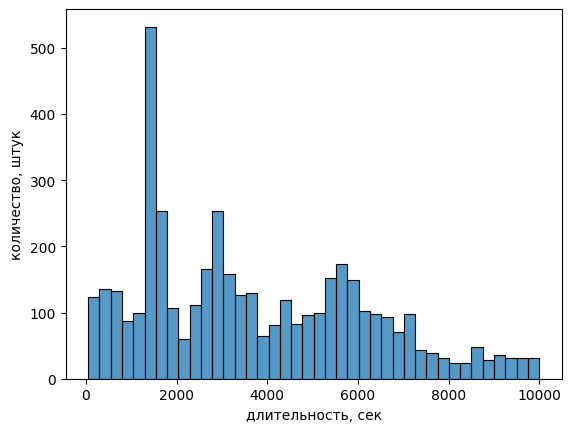

In [10]:
mask1 = main_anime_df['duration']>000
mask2 = main_anime_df['duration']<10000

sns.histplot(main_anime_df['duration'].where(mask1 & mask2), bins=40)

plt.title('')
plt.xlabel('длительность, сек')
plt.ylabel('количество, штук')
plt.show()

И есть под 100 штук аниме, общая длительность которых более 24 часов, зачастую там несколько сотен серий  
из наиболее известных это Наруто и Блич

In [11]:
mask1 = main_anime_df['duration']>1e5

main_anime_df[mask1][['title', 'duration']].sort_values(by='duration', ascending=False).head(7)

,title,duration
1457,Детектив Конан,1775211
1201,Ван-Пис,1698197
101,Наруто: Ураганные хроники,835438
79,Блич,545842
9020,Операция: Семейка Ёдзакура 2,491615
245,Драконий жемчуг Z,430638
116,Боруто: Новое Поколение,426777


## Распределение аниме по количеству эпизодов

Из данных о количестве эпизодов в аниме подтвердаются вывводы сделанные на основании общей продолжительности в секундах:  
Наиболее часто выпускаются сериалы с 11/12/13 эпизодами, 24/25 серийные сериалы и полнометражные фильмы или 1-серийные дополнения

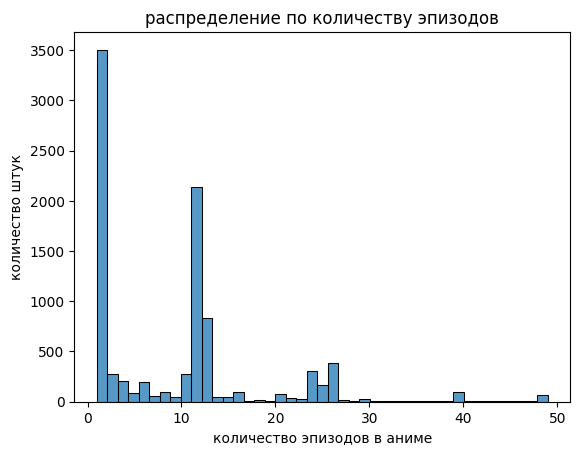

In [164]:
mask = (main_anime_df['episodes_count'] > 0) & (main_anime_df['episodes_count'] < main_anime_df['episodes_count'].quantile(0.96)) 

sns.histplot(main_anime_df[mask]['episodes_count'])

plt.title('распределение по количеству эпизодов')
plt.xlabel('количество эпизодов в аниме')
plt.ylabel('количество штук')
plt.show()

<Axes: xlabel='lists_count', ylabel='Count'>

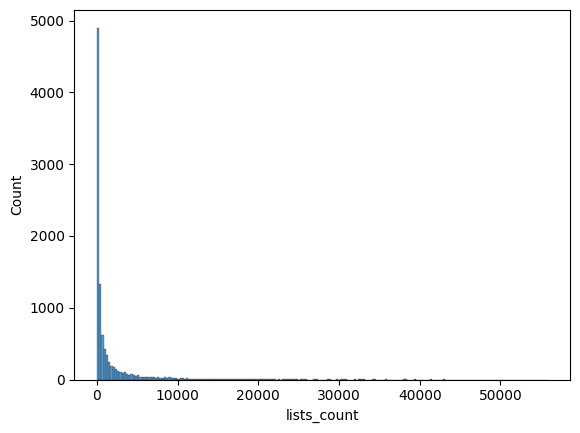

In [ ]:
sns.histplot(main_anime_df['lists_count'].where(main_anime_df['lists_count']>0))


## Распределение аниме по количеству простмотров страцы аниме

показывает популярность тех или иных аниме  
всего на сайте в сумме под 900 миллионов посещений разных аниме  
больше 1 миллиона посещений имеют 135 тайтлов, это 1.3% от всех аниме, а их сумма посещений составляет 35% всех посещений  
50% всех аниме посещали менее 20000 раз  

наибольшее число посещений на сайте у 3го сезона магической битвы (там более 11 миллионов мосещений)  
так же много посещений страни у аниме с большим количеством серий (тех же Наруто и Блича)

In [12]:
print('общее количество посещений:', main_anime_df['views'].sum(), 'раз')

общее количество посещений: 883997869 раз


In [13]:
mask1 = main_anime_df['views']>1e6

print('аниме с 1 миллионом посещений и больше')
print('доля от общего числа просмотров:', f'{main_anime_df['views'].where(mask1).sum() / main_anime_df['views'].sum():.4f}')
print('доля от общего числа аниме:', f'{main_anime_df['views'].where(mask1).count() / main_anime_df['views'].count():.4f}')

аниме с 1 миллионом посещений и больше
доля от общего числа просмотров: 0.3548
доля от общего числа аниме: 0.0132


In [111]:
mask1 = main_anime_df['views'] < 2e4

print('аниме с 20.000 посещений и менее')
print('имеют долю от общего числа просмотров:', f'{main_anime_df['views'].where(mask1).count() / main_anime_df['views'].count():.2f}')

аниме с 20.000 посещений и менее
имеют долю от общего числа просмотров: 0.51


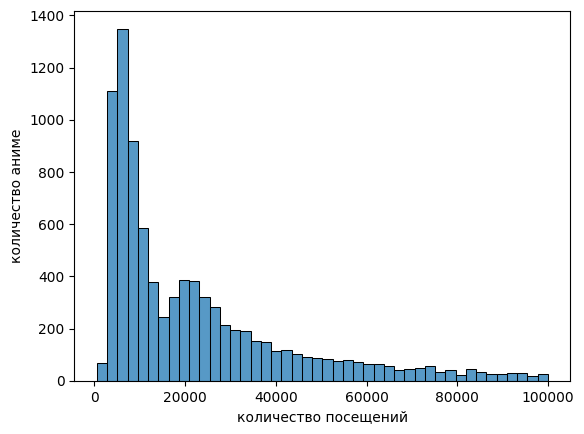

In [ ]:
mask1 = main_anime_df['views'] > 0
mask2 = main_anime_df['views'] < 1e5

sns.histplot(main_anime_df['views'].where(mask1 & mask2))


plt.title('')
plt.xlabel('количество посещений')
plt.ylabel('количество аниме')
plt.show()

In [122]:
mask1 = main_anime_df['views'] > 1e6

main_anime_df[mask1][['title', 'views']].sort_values(by='views', ascending=False).head(7)

,title,views
8017,Магическая битва: Смертельная миграция,11234866
8704,Гачиакута,9910383
7241,Адский рай 2,9204655
1201,Ван-Пис,9167028
101,Наруто: Ураганные хроники,6259384
79,Блич,5697901
7168,Ванпанчмен 3,5263528


## Распределение аниме по оценкам

Не у всех произведений стоит оценка:  
из 10197 наименований оценка стоит только у 9672 аниме  
(на сайте оценок нет у анонсированных, но еще не вышедших аниме)

In [49]:
mask1 = main_anime_df['y_rating_avg'] > 0
print('количество аниме с оценкой выше 0:', main_anime_df['y_rating_avg'].where(mask1).count())

print('средняя оценка всех аниме на сайте:', main_anime_df['y_rating_avg'].where(mask1).mean())

количество аниме с оценкой выше 0: 9672
средняя оценка всех аниме на сайте: 6.76597623230166


Сравнение распределений оценок с 

In [54]:
mask1 = main_anime_df['year'] < 2027
mask2 = main_anime_df['y_rating_avg'] == 0
main_anime_df[mask1 & mask2][['title', 'year', 'views']]


,title,year,views
14,Необъятный океан 3,2026,179425
152,Чтение про себя,0,37431
1262,Военная хроника маленькой девочки 2,2026,182023
6923,Детектив уже мертв 2,2026,57838
7102,О моём перерождении в меч 2,2026,148134
...,...,...,...
10186,Кулак Северной звезды: Реквием по рядовым голо...,2026,1619
10191,Восемь небожителей!,2026,657
10192,Демонический детектив династии Тан,2026,1129
10194,За гранью времени 2,2026,2228


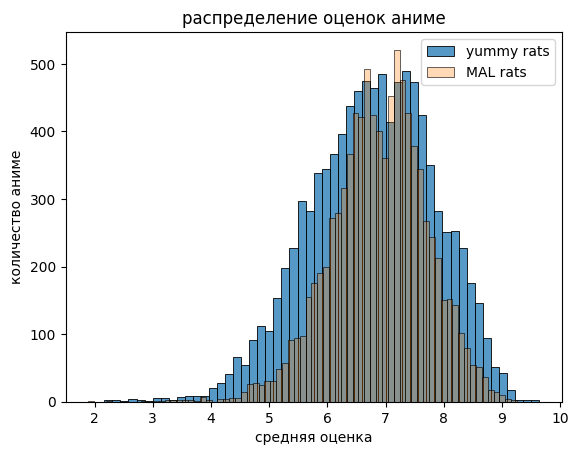

In [88]:
mask1 = main_anime_df['y_rating_avg'] > 0
mask2 = main_anime_df['myanimelist_rating'] > 0

sns.histplot(main_anime_df['y_rating_avg'].where(mask1), label='yummy rats')
sns.histplot(main_anime_df['myanimelist_rating'].where(mask2), alpha=0.3, label='MAL rats')

plt.title('распределение оценок аниме')
plt.xlabel('средняя оценка')
plt.ylabel('количество аниме')
plt.legend()
plt.show()

In [ ]:
main_anime_df['y_rating_int'] = main_anime_df['y_rating_avg'].astype(int)
main_anime_df["y_rating_rnd"] = main_anime_df["y_rating_avg"].round().astype(int)


In [79]:
conditions = [
    main_anime_df["y_rating_avg"] < 5,
    main_anime_df["y_rating_avg"].between(5, 6, inclusive="left"),
    main_anime_df["y_rating_avg"] .between(6, 8, inclusive="left"),
    main_anime_df["y_rating_avg"].between(8, 9, inclusive="left"),
    main_anime_df["y_rating_avg"] > 9,
]

choices = [1, 2, 3, 4, 5]

main_anime_df["my_rat"] = np.select(conditions, choices, default=np.nan)

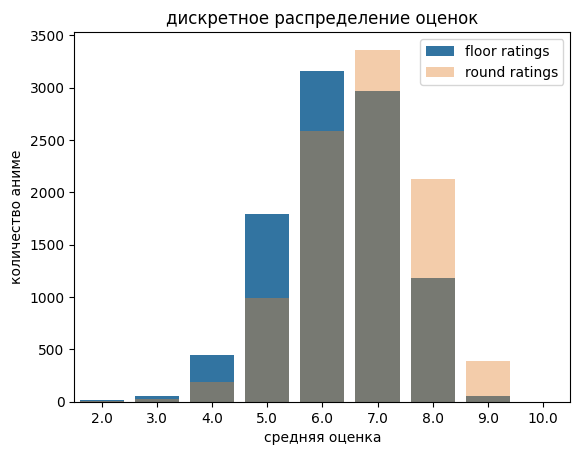

In [ ]:
mask1 = main_anime_df['y_rating_int'] > 0

ratings_1 = main_anime_df['y_rating_int'].where(mask1).value_counts()
ratings_2 = main_anime_df['y_rating_rnd'].where(mask1).value_counts()

sns.barplot(ratings_1, label='floor ratings')
sns.barplot(ratings_2, alpha=0.4, label='round ratings')

plt.title('дискретное распределение оценок')
plt.xlabel('средняя оценка')
plt.ylabel('количество аниме')
plt.legend()
plt.show()

Ниже график показывает как изменяется средняя оценка аниме в зависимости года выпуска   
До начала 2000 идет устойчивый тренд на увеличение средней оценки  
Пик достигается в 2008 году с значением в 7.06  
Примерно до 2015 средняя оценка за аниме остается на тех же значениях, около 6.95-7.00  
и после 2015 наблюдается тренд на снижение средних оценок  
(2026 не включен)

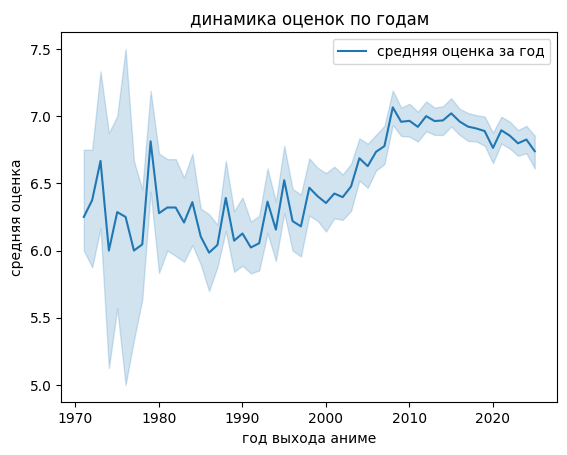

In [99]:
mask = (main_anime_df['y_rating_int'] > 0) & (main_anime_df['year'] > 1970) & (main_anime_df['year'] < 2026)

sns.lineplot(data=main_anime_df[mask], x='year', y='y_rating_rnd', label='средняя оценка за год')

plt.title('динамика оценок по годам')
plt.xlabel('год выхода аниме')
plt.ylabel('средняя оценка')
plt.legend()
plt.show()

In [106]:
mask = (main_anime_df['y_rating_int'] > 0) & (main_anime_df['year'] > 1970) & (main_anime_df['year'] < 2026)

main_anime_df[mask].groupby(by=['year'])['y_rating_rnd'].mean()

year
1971    6.250000
1972    6.375000
1973    6.666667
1974    6.000000
1975    6.285714
1976    6.250000
1977    6.000000
1978    6.045455
1979    6.812500
1980    6.277778
1981    6.320000
1982    6.320000
1983    6.208333
1984    6.360000
1985    6.104167
1986    5.984127
1987    6.041096
1988    6.391304
1989    6.073171
1990    6.126761
1991    6.022727
1992    6.054054
1993    6.363636
1994    6.155844
1995    6.523256
1996    6.218750
1997    6.179775
1998    6.467391
1999    6.403846
2000    6.353535
2001    6.424000
2002    6.397059
2003    6.476510
2004    6.686391
2005    6.627778
2006    6.734783
2007    6.776824
2008    7.065116
2009    6.957806
2010    6.965066
2011    6.920290
2012    7.000000
2013    6.963455
2014    6.967836
2015    7.020710
2016    6.960199
2017    6.922078
2018    6.908235
2019    6.888889
2020    6.763441
2021    6.894737
2022    6.854911
2023    6.797774
2024    6.825670
2025    6.739130
Name: y_rating_rnd, dtype: float64

можно попробовать найти зависимость между оценкой аниме и количеством посещений  
У большинства аниме относительно малое количество посещений и оценка могут быть из всего диапазона значений  
Но с ростом количества посещений средняя оценка аниме растет, а самые низкие оценки зачастую у наименнее посещаемых аниме  

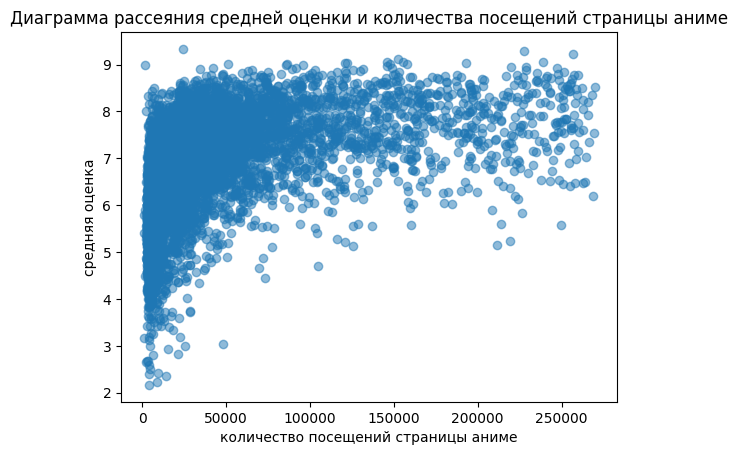

In [157]:
mask = (main_anime_df['y_rating_avg'] > 0) & (main_anime_df['views'] < main_anime_df['views'].quantile(0.94))

plt.scatter(main_anime_df[mask]['views'], main_anime_df[mask]['y_rating_avg'], alpha=0.5)

plt.title('Диаграмма рассеяния средней оценки и количества посещений страницы аниме')
plt.xlabel('количество посещений страницы аниме')
plt.ylabel('средняя оценка')
# plt.legend()
plt.show()

Аналогичную тенденцию можно заметить и на количестве оставленных комментариев:  
Чем больше оставленно комментариев под аниме (тем оно популярнее) и средняя оценка выше у таких аниме  
и наоборот низшая оценка стоит зачасту у аниме с малым количеством комментариев  

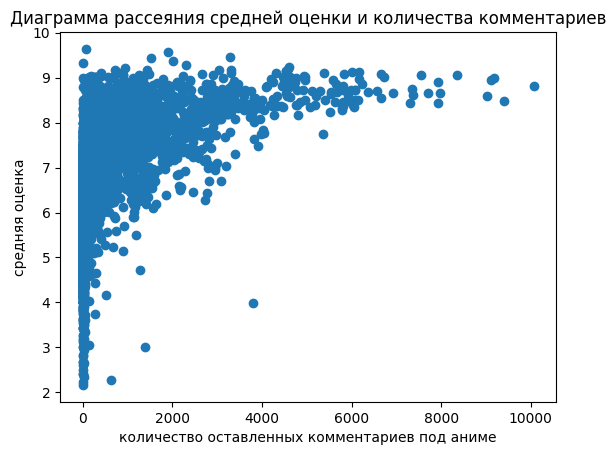

In [160]:
mask_v = (main_anime_df['y_rating_avg'] > 0) & (main_anime_df['count'] < main_anime_df['views'].quantile(0.95)) 

plt.scatter(main_anime_df['count'][mask_v], main_anime_df['y_rating_avg'][mask_v])

plt.title('Диаграмма рассеяния средней оценки и количества комментариев')
plt.xlabel('количество оставленных комментариев под аниме')
plt.ylabel('средняя оценка')
plt.show()

По статусу на сайте аниме делятся на вышедшие (9525 штук), анонсированные (528 штук) и те что выходят сейчас (144)

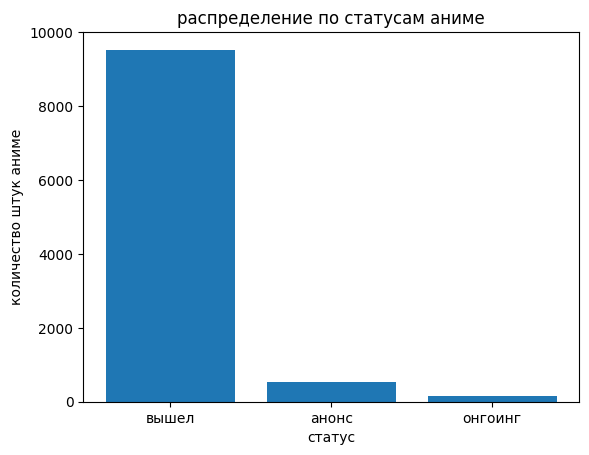

In [137]:
x = main_anime_df['status_ru'].value_counts().index
y = main_anime_df['status_ru'].value_counts().values

plt.bar(x, y)

plt.title('распределение по статусам аниме')
plt.xlabel('статус')
plt.ylabel('количество штук аниме')
# plt.legend()
plt.show()

По типу на сайте аниме делятся на Сериал, ONA(без показ на тв), OVA(некое дополнение),'Полнометражные фильмы, Спешлы, Малометражный сериал, Короткометражный фильмы, 

In [ ]:
main_anime_df['type_ru'].value_counts()

type_ru
Сериал                    4172
ONA                       1733
OVA                       1369
Полнометражный фильм      1329
Спешл                      819
Малометражный сериал       375
Короткометражный фильм     305
Неизвестно                  95
Name: count, dtype: int64

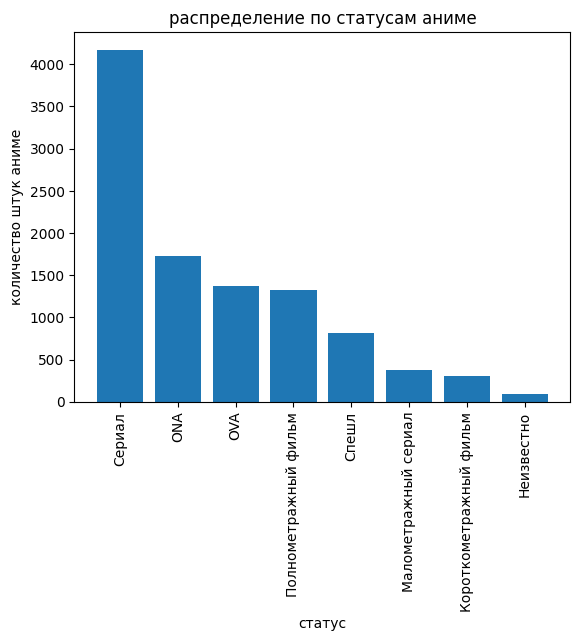

In [146]:
x = main_anime_df['type_ru'].value_counts().index
y = main_anime_df['type_ru'].value_counts().values

plt.bar(x, y)

plt.title('распределение по статусам аниме')
plt.xlabel('статус')
plt.xticks(rotation=90)
plt.ylabel('количество штук аниме')
# plt.legend()
plt.show()

# genres

In [ ]:
genres_df = pd.read_sql_query(
    '''
    SELECT *
    FROM anime_main AS m
        LEFT JOIN ratings AS r ON r.anime_id = m.anime_id
        LEFT JOIN ratings_distributions AS rd ON rd.anime_id = m.anime_id
        LEFT JOIN genres AS g on g.anime_id = m.anime_id
    ORDER BY m.anime_id
    ''',
    posgdb.conn
)

genres_copy = genres_df.copy()

C:\Users\gusen\AppData\Local\Temp\ipykernel_22972\1459233540.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  genres_df = pd.read_sql_query(


In [125]:
genres_df.head()

,anime_id,genre_id,title_ru,title_en,url
0,1,32,Приключения,priklyucheniya,/catalog/category/priklyucheniya
1,1,42,Фэнтези,fentezi,/catalog/category/fentezi
2,1,47,Ведьмы,ved-my,/catalog/category/ved-my
3,2,10,Сэйнэн,sejnen,/catalog/category/sejnen
4,2,15,Драма,drama,/catalog/category/drama


In [126]:
genres_copy.groupby('anime_id').count()

,genre_id,title_ru,title_en,url
anime_id,,,,
1,3,3,3,3
2,5,5,5,5
3,6,6,6,6
4,2,2,2,2
5,4,4,4,4
...,...,...,...,...
29077,3,3,3,3
29078,5,5,5,5
29117,5,5,5,5


# videos

In [127]:
videos_df = pd.read_sql_query(
    '''
    SELECT *
    FROM videos
    ORDER BY anime_id
    ''',
    posgdb.conn
)

videos_copy = videos_df.copy()

C:\Users\gusen\AppData\Local\Temp\ipykernel_22972\2793606113.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  videos_df = pd.read_sql_query(


In [128]:
videos_copy.groupby('anime_id').count()

,video_id,episode_number,player_id,player_name,dubbing_name,date,vid_index,views,duration
anime_id,,,,,,,,,
1,2,2,2,2,2,2,2,2,2
2,6,6,6,6,6,2,6,6,6
3,168,168,168,168,168,48,168,168,168
4,60,60,60,60,60,42,60,60,60
5,75,75,75,75,75,75,75,75,75
...,...,...,...,...,...,...,...,...,...
28708,1,1,1,1,1,1,1,1,1
28819,13,13,13,13,13,13,13,13,13
28932,1,1,1,1,1,1,1,1,1


In [130]:
videos_copy['episode_number'].value_counts()

episode_number
1        55323
2        45762
3        44099
4        42891
5        41697
         ...  
20a          1
20b          1
24.5         1
1-22         1
23-33        1
Name: count, Length: 1329, dtype: int64